# EDA — `train_processed.csv`

Análisis exploratorio del dataset de propiedades inmobiliarias en Florida.

- **Filas:** 11.840 propiedades
- **Columnas:** 46 features (estructura, ubicación, impuestos, escuelas, tags, texto)
- **Target principal:** `log_price` (logaritmo del precio de venta ajustado por HPI)

## Diccionario de columnas

Descripción de cada variable del dataset, agrupada por tipo.

### Identificación y target

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `zpid` | int | Identificador único de la propiedad en Zillow. Sirve como ID de fila, no es una feature predictiva. |
| `lastSoldPrice_hpi_adjusted` | float | Precio de la última venta ajustado por el **Home Price Index (HPI)**. Corrige el precio histórico a valores equivalentes en el tiempo. Expresado en USD. |
| `log_price` | float | Logaritmo natural del precio ajustado (`ln(lastSoldPrice_hpi_adjusted)`). Es la **variable objetivo** principal para modelado. |

### Estructura de la propiedad

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `bedrooms` | float | Cantidad de dormitorios. |
| `bathrooms` | float | Cantidad de baños (puede incluir medios baños, ej. 2.5). |
| `livingArea` | float | Superficie habitable en **pies cuadrados (sqft)**. |
| `yearBuilt` | float | Año de construcción de la propiedad. |
| `property_age` | float | Edad de la propiedad en años al momento del registro (`año actual − yearBuilt`). Feature derivada. |
| `bath_to_bed_ratio` | float | Ratio baños/dormitorios. Feature derivada que resume la relación entre ambos. |
| `log_living_area` | float | Logaritmo natural de `livingArea`. Feature derivada para capturar relaciones no lineales con el área. |
| `lotAreaValue` | float | Superficie del lote/terreno en **pies cuadrados**. Suele faltar en condos/apartments (~45% missing). |
| `log_lot_area` | float | Logaritmo natural de `lotAreaValue`. Feature derivada. |
| `homeType` | str | Tipo de propiedad: `SINGLE_FAMILY`, `CONDO`, `TOWNHOUSE`, `APARTMENT`, `MULTI_FAMILY`, etc. |
| `photoCount` | int | Cantidad de fotos publicadas en el listado. |

### Ubicación

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `latitude` | float | Latitud geográfica (Florida, ~25.5°–30.6°). |
| `longitude` | float | Longitud geográfica (Florida, ~−85.6° a −80.0°). |
| `zipcode` | int | Código postal completo de 5 dígitos (ej. 33460). |
| `zip_3digit` | int | Primeros 3 dígitos del zipcode. Agrupa propiedades por zona geográfica más amplia. |

### Impuestos y valoración fiscal

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `taxAssessedValue` | float | Valor de la propiedad según la **tasación fiscal** del condado (assessed value), en USD. |
| `propertyTaxRate` | float | Tasa impositiva anual aplicada sobre el valor tasado (porcentaje). |
| `latest_tax_value` | float | Valor tasado más reciente registrado en el historial de impuestos, en USD. |
| `latest_tax_paid` | float | Monto del último impuesto a la propiedad pagado, en USD. |
| `num_tax_records` | float | Cantidad de registros de impuestos disponibles en el historial de la propiedad. |

### Historial de ventas y listados

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `num_sales` | float | Cantidad de ventas registradas en el historial de la propiedad. |
| `num_price_changes` | float | Cantidad de cambios de precio en el historial de listados. |
| `last_listing_price` | float | Último precio de publicación antes de la venta, en USD. Faltante si nunca se listó (~33%). |

### Escuelas cercanas

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `avg_school_rating` | float | Rating promedio de las escuelas cercanas (escala ~1–5). |
| `max_school_rating` | float | Rating máximo entre las escuelas cercanas. |
| `num_nearby_schools` | float | Cantidad de escuelas en las proximidades. |
| `min_school_distance` | float | Distancia mínima a una escuela cercana (en millas). |

### HOA y amenities

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `has_hoa` | float | Indica si la propiedad tiene **HOA** (Homeowners Association). 1 = sí, 0 = no. |
| `hoa_fee_monthly` | float | Cuota mensual de la HOA en USD. 0 si no aplica. |
| `has_pool` | int | Indica si la propiedad tiene piscina. 1 = sí, 0 = no. |
| `has_garage` | int | Indica si la propiedad tiene garaje. 1 = sí, 0 = no. |
| `has_waterfront` | int | Indica si la propiedad tiene frente al agua (waterfront). 1 = sí, 0 = no. |

### Tags de listado

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `tag_price_cut` | int | Tag que indica reducción de precio en el listado. 1 = sí, 0 = no. |
| `tag_new_construction` | int | Tag de construcción nueva. 1 = sí, 0 = no. |
| `tag_foreclosure` | int | Tag de propiedad en ejecución hipotecaria (foreclosure). 1 = sí, 0 = no. |

### Descripción textual

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `description` | str | Texto libre de la descripción del listado (dirección, m², tipo, etc.). |
| `desc_length` | int | Cantidad de caracteres de la descripción. Feature derivada del texto. |
| `desc_word_count` | int | Cantidad de palabras de la descripción. Feature derivada del texto. |
| `desc_is_boilerplate` | int | Indica si la descripción es un texto genérico/autogenerado (boilerplate). 1 = sí, 0 = no. |
| `desc_mentions_renovated` | int | La descripción menciona que la propiedad fue renovada. 1 = sí, 0 = no. |
| `desc_mentions_pool` | int | La descripción menciona piscina. 1 = sí, 0 = no. |
| `desc_mentions_view` | int | La descripción menciona vista (ej. "ocean view"). 1 = sí, 0 = no. |
| `desc_mentions_new` | int | La descripción menciona que es nueva o recién construida. 1 = sí, 0 = no. |

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

DATA_PATH = "train_processed.csv"

## 1. Carga y vista general

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Shape: 11,840 filas × 46 columnas
Memoria: 9.2 MB


,zpid,lastSoldPrice_hpi_adjusted,log_price,description,bedrooms,bathrooms,livingArea,yearBuilt,latitude,longitude,...,log_living_area,log_lot_area,zip_3digit,desc_length,desc_word_count,desc_is_boilerplate,desc_mentions_renovated,desc_mentions_pool,desc_mentions_view,desc_mentions_new
0,1011541,255691.210988,12.451730,This 665 square foot condo home has 1 bedrooms...,1.0,1.0,665.0,2006.0,26.616192,-80.054060,...,6.501290,0.693147,334,136,26,1,0,0,0,0
1,1005445,687261.362622,13.440471,This 1030 square foot condo home has 2 bedroom...,2.0,2.0,1030.0,1987.0,25.847658,-80.145710,...,6.938284,NaN,331,148,28,1,0,0,0,0
2,1002822,264917.298188,12.487177,This 980 square foot condo home has 2 bedrooms...,2.0,2.0,980.0,1974.0,26.307700,-80.095030,...,6.888572,NaN,334,140,27,1,0,0,0,0
3,1006212,861474.563930,13.666402,This 1237 square foot condo home has 2 bedroom...,2.0,2.0,1237.0,1970.0,25.987293,-80.118614,...,7.121252,7.121252,330,137,26,1,0,0,0,0
4,1007959,314224.747125,12.657867,This 978 square foot single family home has 3 ...,3.0,2.0,978.0,1961.0,26.580450,-80.104880,...,6.886532,8.836810,334,137,25,1,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11840 entries, 0 to 11839
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zpid                        11840 non-null  int64  
 1   lastSoldPrice_hpi_adjusted  11840 non-null  float64
 2   log_price                   11840 non-null  float64
 3   description                 11840 non-null  str    
 4   bedrooms                    11360 non-null  float64
 5   bathrooms                   11615 non-null  float64
 6   livingArea                  11668 non-null  float64
 7   yearBuilt                   11529 non-null  float64
 8   latitude                    11809 non-null  float64
 9   longitude                   11809 non-null  float64
 10  lotAreaValue                6494 non-null   float64
 11  photoCount                  11840 non-null  int64  
 12  taxAssessedValue            11316 non-null  float64
 13  propertyTaxRate             11838 non-null

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
zpid,11840.0,1.008799e+06,5070.508780,1.000001e+06,1.004382e+06,1.008754e+06,1.013184e+06,1.017606e+06
lastSoldPrice_hpi_adjusted,11840.0,5.590194e+05,350971.426392,5.127585e+04,3.039663e+05,4.722890e+05,7.292780e+05,1.986843e+06
log_price,11840.0,1.303255e+01,0.663308,1.084499e+01,1.262468e+01,1.306535e+01,1.349981e+01,1.450206e+01
bedrooms,11360.0,2.446743e+00,1.047838,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,1.100000e+01
bathrooms,11615.0,1.973250e+00,0.752093,0.000000e+00,1.500000e+00,2.000000e+00,2.000000e+00,1.000000e+01
livingArea,11668.0,1.417349e+03,669.386605,0.000000e+00,9.700000e+02,1.311000e+03,1.728250e+03,2.516300e+04
yearBuilt,11529.0,1.975436e+03,21.475135,1.900000e+03,1.960000e+03,1.973000e+03,1.989000e+03,2.027000e+03
latitude,11809.0,2.603754e+01,0.388740,2.550669e+01,2.573327e+01,2.590254e+01,2.638051e+01,3.056273e+01
longitude,11809.0,-8.017965e+01,0.135932,-8.563624e+01,-8.024315e+01,-8.016241e+01,-8.008261e+01,-8.003413e+01
lotAreaValue,6494.0,4.679380e+03,3457.822771,0.000000e+00,9.970000e+02,5.501000e+03,7.500750e+03,1.873080e+04


## 2. Valores faltantes

In [5]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="n_missing")
)
missing["pct_missing"] = (missing["n_missing"] / len(df) * 100).round(2)
missing = missing[missing["n_missing"] > 0]

print(f"Columnas con al menos un missing: {len(missing)}")
missing

Columnas con al menos un missing: 16


,n_missing,pct_missing
lotAreaValue,5346,45.15
log_lot_area,5346,45.15
last_listing_price,3925,33.15
bath_to_bed_ratio,582,4.92
latest_tax_paid,539,4.55
latest_tax_value,525,4.43
taxAssessedValue,524,4.43
bedrooms,480,4.05
property_age,311,2.63
yearBuilt,311,2.63


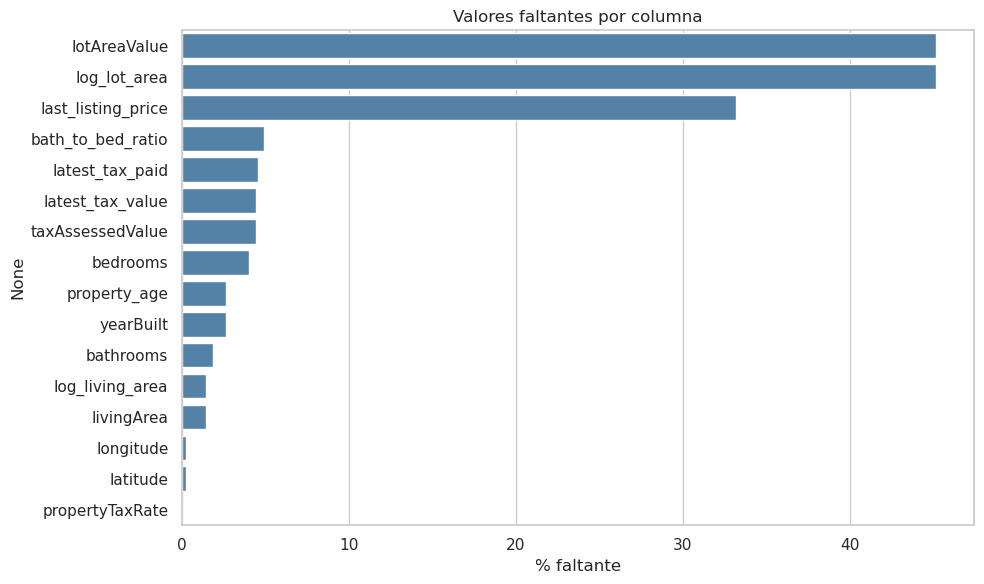

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=missing["pct_missing"].values,
    y=missing.index,
    orient="h",
    ax=ax,
    color="steelblue",
)
ax.set_xlabel("% faltante")
ax.set_title("Valores faltantes por columna")
plt.tight_layout()
plt.show()

## 3. Variable objetivo

Analizamos `log_price` y su equivalente en escala original (`lastSoldPrice_hpi_adjusted`).

In [7]:
target_cols = ["log_price", "lastSoldPrice_hpi_adjusted"]
df[target_cols].describe()

,log_price,lastSoldPrice_hpi_adjusted
count,11840.000000,1.184000e+04
mean,13.032547,5.590194e+05
std,0.663308,3.509714e+05
min,10.844995,5.127585e+04
25%,12.624675,3.039663e+05
50%,13.065349,4.722890e+05
75%,13.499812,7.292780e+05
max,14.502058,1.986843e+06


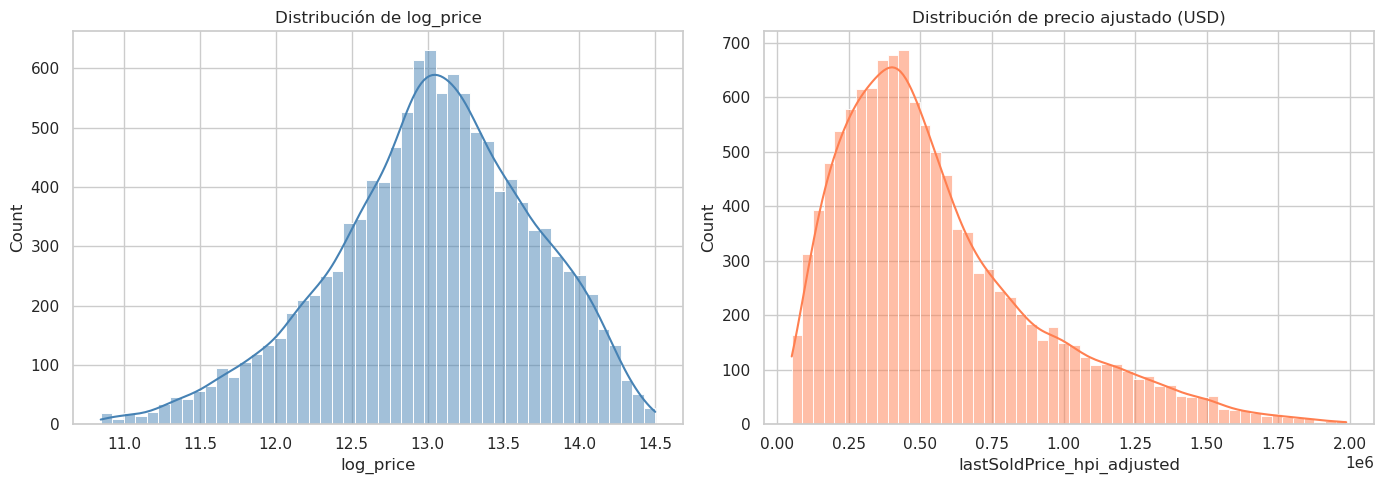

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["log_price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de log_price")
axes[0].set_xlabel("log_price")

sns.histplot(df["lastSoldPrice_hpi_adjusted"], kde=True, ax=axes[1], color="coral")
axes[1].set_title("Distribución de precio ajustado (USD)")
axes[1].set_xlabel("lastSoldPrice_hpi_adjusted")

plt.tight_layout()
plt.show()

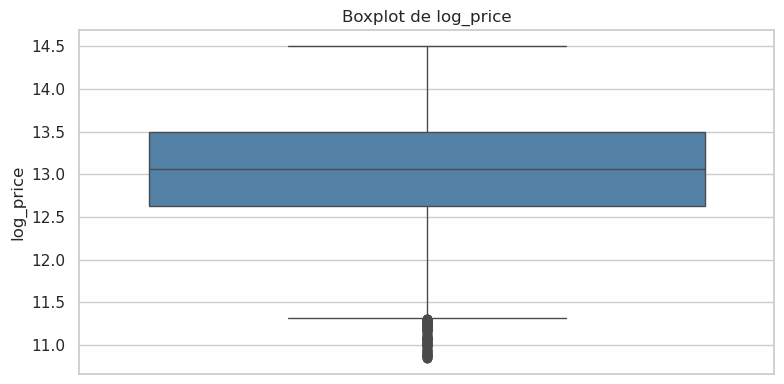

Outliers (IQR): 117 (1.0%)


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(y=df["log_price"], ax=ax, color="steelblue")
ax.set_title("Boxplot de log_price")
plt.tight_layout()
plt.show()

q1, q3 = df["log_price"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df["log_price"] < q1 - 1.5 * iqr) | (df["log_price"] > q3 + 1.5 * iqr)]
print(f"Outliers (IQR): {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

## 4. Features numéricas clave

Distribuciones de las variables estructurales y de valor más relevantes.

In [10]:
key_numeric = [
    "bedrooms", "bathrooms", "livingArea", "yearBuilt", "property_age",
    "lotAreaValue", "taxAssessedValue", "avg_school_rating", "hoa_fee_monthly",
]

df[key_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
bedrooms,11360.0,2.446743,1.047838,0.000000,2.0,2.0,3.00,1.100000e+01
bathrooms,11615.0,1.973250,0.752093,0.000000,1.5,2.0,2.00,1.000000e+01
livingArea,11668.0,1417.349417,669.386605,0.000000,970.0,1311.0,1728.25,2.516300e+04
yearBuilt,11529.0,1975.436204,21.475135,1900.000000,1960.0,1973.0,1989.00,2.027000e+03
property_age,11529.0,49.563796,21.475135,-2.000000,36.0,52.0,65.00,1.250000e+02
lotAreaValue,6494.0,4679.379708,3457.822771,0.000000,997.0,5501.0,7500.75,1.873080e+04
taxAssessedValue,11316.0,304907.683369,210222.886740,300.000000,151734.0,253835.5,399658.75,1.744567e+06
avg_school_rating,11840.0,5.041484,1.335322,2.333333,4.0,5.0,6.00,9.000000e+00
hoa_fee_monthly,11840.0,301.829364,1274.460604,0.000000,0.0,45.0,417.25,9.711600e+04


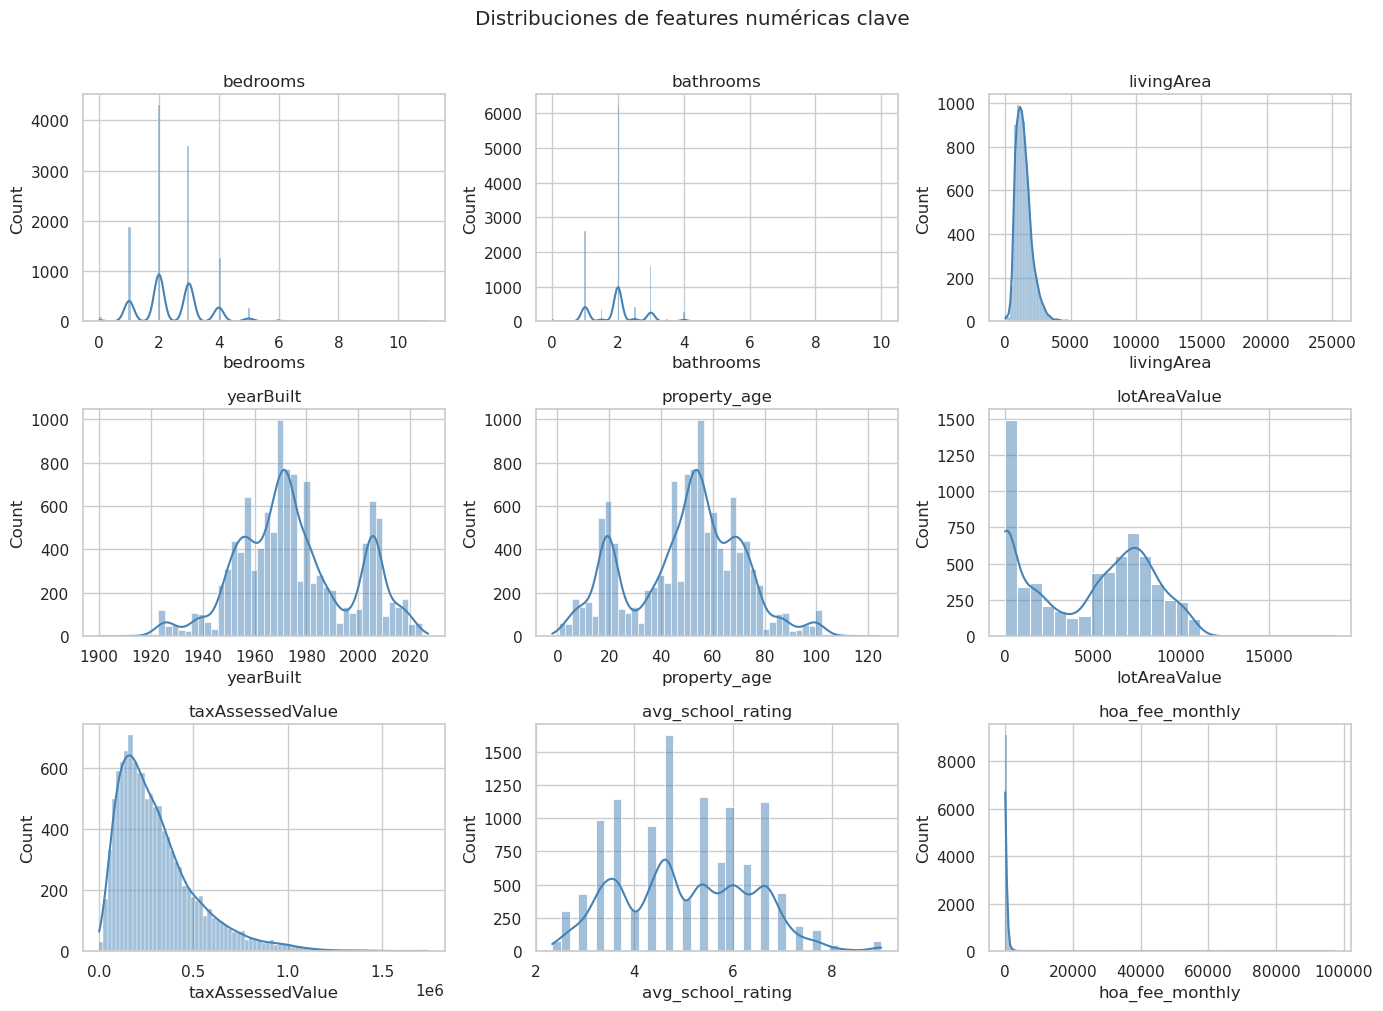

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, key_numeric):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)

plt.suptitle("Distribuciones de features numéricas clave", y=1.01)
plt.tight_layout()
plt.show()

## 5. Features categóricas

In [12]:
home_counts = df["homeType"].value_counts()
home_counts

homeType
SINGLE_FAMILY        4900
CONDO                4723
TOWNHOUSE             920
APARTMENT             640
MULTI_FAMILY          555
HOME_TYPE_UNKNOWN      46
MANUFACTURED           36
LOT                    20
Name: count, dtype: int64

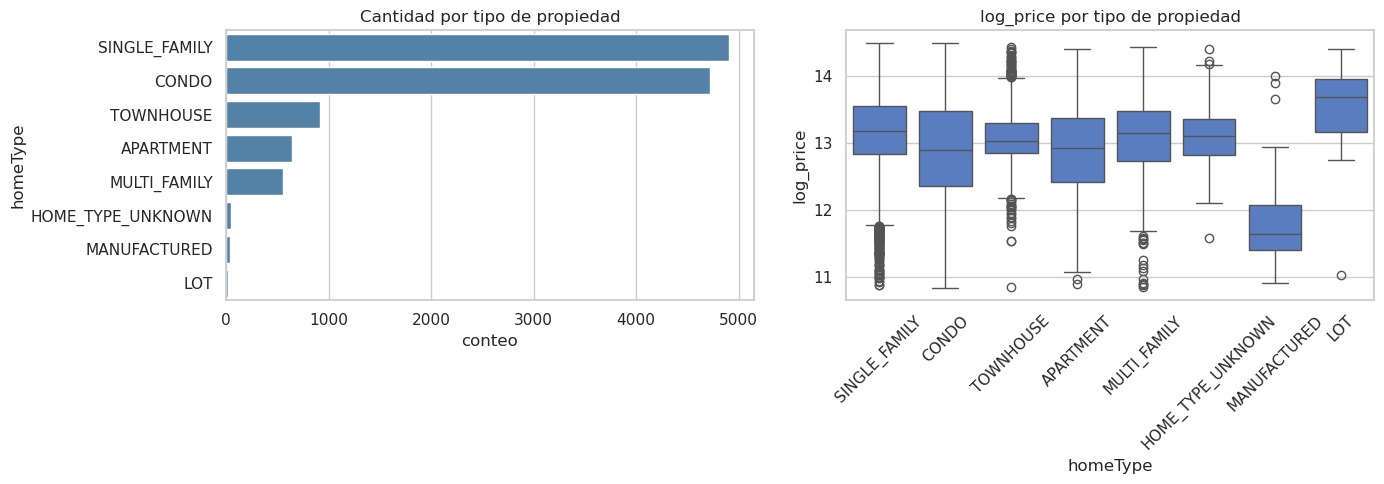

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(y=df["homeType"], order=home_counts.index, ax=axes[0], color="steelblue")
axes[0].set_title("Cantidad por tipo de propiedad")
axes[0].set_xlabel("conteo")

sns.boxplot(data=df, x="homeType", y="log_price", order=home_counts.index, ax=axes[1])
axes[1].set_title("log_price por tipo de propiedad")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

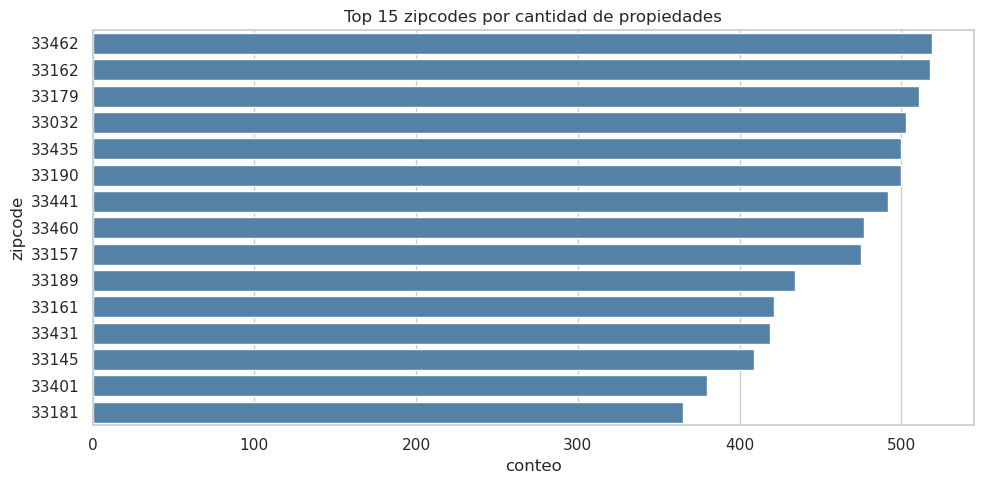

In [14]:
top_zips = df["zipcode"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_zips.values, y=top_zips.index.astype(str), orient="h", ax=ax, color="steelblue")
ax.set_title("Top 15 zipcodes por cantidad de propiedades")
ax.set_xlabel("conteo")
plt.tight_layout()
plt.show()

## 6. Correlaciones

Matriz de correlación entre variables numéricas y el target.

In [15]:
numeric_df = df.select_dtypes(include=np.number)
corr_target = numeric_df.corr()["log_price"].drop("log_price").sort_values(key=abs, ascending=False)

print("Top 15 correlaciones con log_price:")
corr_target.head(15)

Top 15 correlaciones con log_price:


lastSoldPrice_hpi_adjusted    0.923615
taxAssessedValue              0.698399
latest_tax_value              0.698388
latest_tax_paid               0.646864
livingArea                    0.484654
log_living_area               0.483640
last_listing_price            0.475029
bathrooms                     0.404420
bedrooms                      0.346836
max_school_rating             0.292977
avg_school_rating             0.278378
photoCount                    0.139889
latitude                     -0.127270
has_garage                    0.127100
log_lot_area                 -0.120356
Name: log_price, dtype: float64

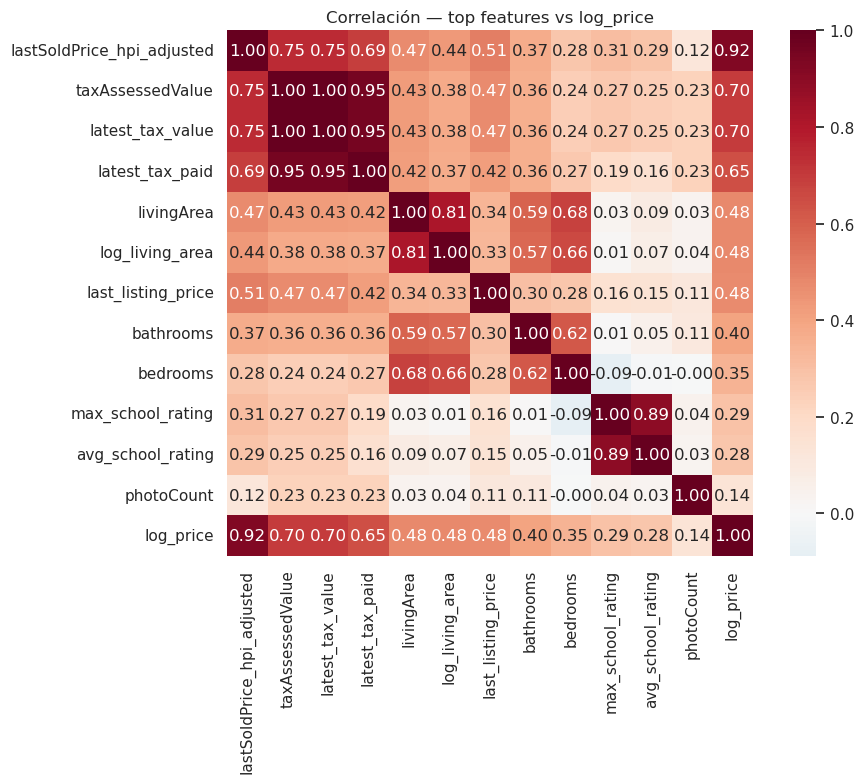

In [16]:
top_features = corr_target.head(12).index.tolist() + ["log_price"]
corr_matrix = numeric_df[top_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Correlación — top features vs log_price")
plt.tight_layout()
plt.show()

## 7. Relaciones bivariadas con el target

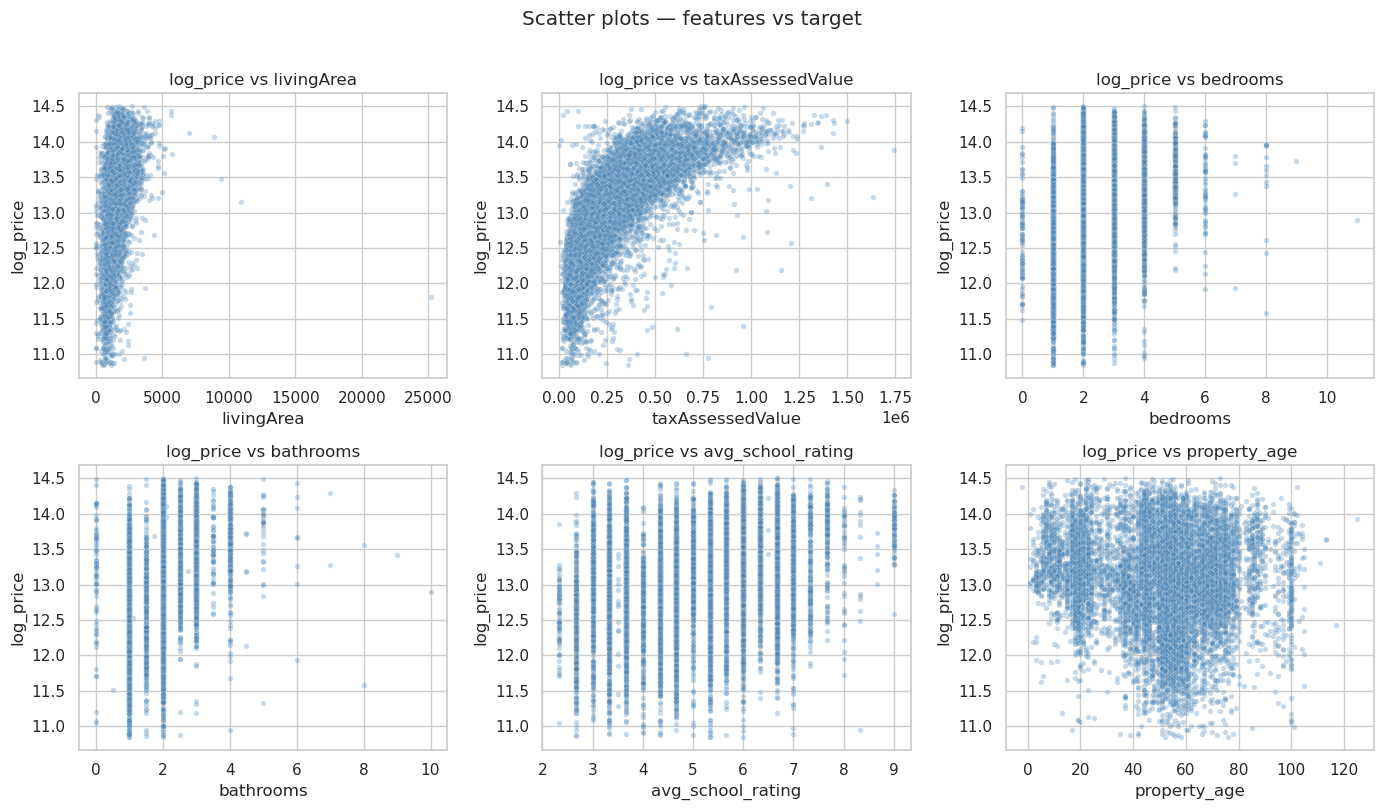

In [17]:
scatter_features = [
    "livingArea", "taxAssessedValue", "bedrooms", "bathrooms",
    "avg_school_rating", "property_age",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, scatter_features):
    sns.scatterplot(
        data=df,
        x=col,
        y="log_price",
        alpha=0.3,
        s=15,
        ax=ax,
        color="steelblue",
    )
    ax.set_title(f"log_price vs {col}")

plt.suptitle("Scatter plots — features vs target", y=1.01)
plt.tight_layout()
plt.show()

## 8. Distribución geográfica

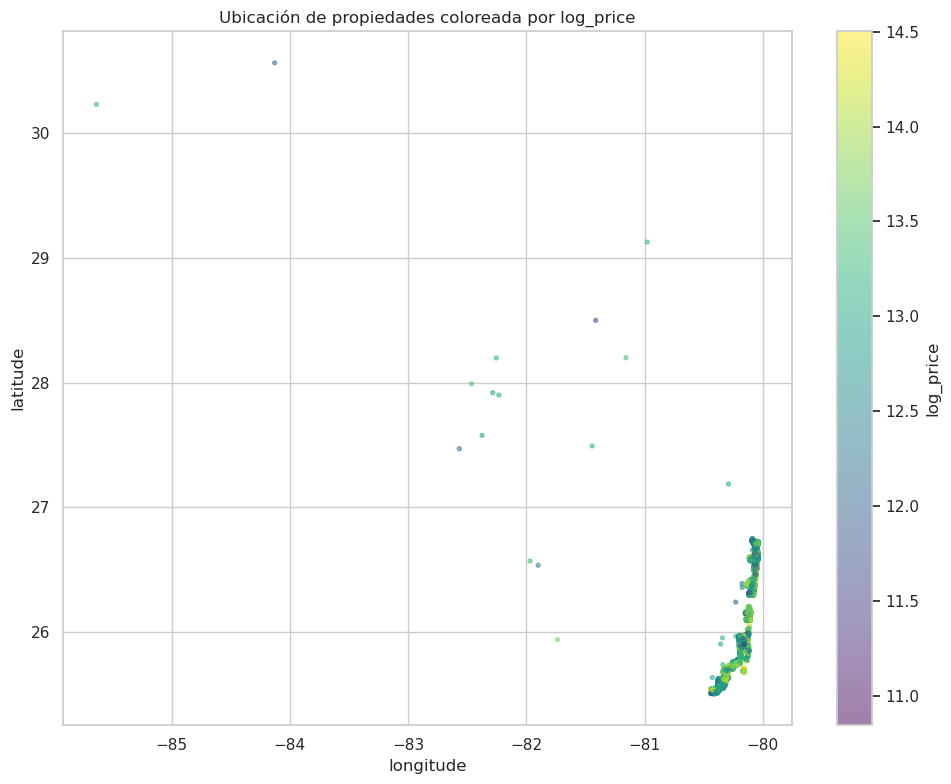

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["log_price"],
    cmap="viridis",
    alpha=0.5,
    s=8,
)
plt.colorbar(scatter, ax=ax, label="log_price")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Ubicación de propiedades coloreada por log_price")
plt.tight_layout()
plt.show()

## 9. Features binarias y tags

In [19]:
binary_cols = [
    "has_hoa", "has_pool", "has_garage", "has_waterfront",
    "tag_price_cut", "tag_new_construction", "tag_foreclosure",
    "desc_is_boilerplate", "desc_mentions_renovated", "desc_mentions_pool",
    "desc_mentions_view", "desc_mentions_new",
]

binary_summary = pd.DataFrame({
    "conteo_1": [df[c].sum() for c in binary_cols],
    "pct_1": [(df[c].sum() / len(df) * 100).round(1) for c in binary_cols],
    "log_price_mean_0": [df.loc[df[c] == 0, "log_price"].mean() for c in binary_cols],
    "log_price_mean_1": [df.loc[df[c] == 1, "log_price"].mean() for c in binary_cols],
}, index=binary_cols)

binary_summary["diff_price"] = (
    binary_summary["log_price_mean_1"] - binary_summary["log_price_mean_0"]
).round(3)

binary_summary.sort_values("diff_price", ascending=False)

,conteo_1,pct_1,log_price_mean_0,log_price_mean_1,diff_price
tag_new_construction,2.0,0.0,13.032405,13.874842,0.842
desc_mentions_view,412.0,3.5,13.020011,13.380273,0.360
has_garage,801.0,6.8,13.009838,13.345510,0.336
has_waterfront,671.0,5.7,13.016380,13.301654,0.285
tag_foreclosure,11.0,0.1,13.032320,13.276248,0.244
desc_mentions_pool,2231.0,18.8,12.999114,13.176543,0.177
has_pool,2231.0,18.8,12.999114,13.176543,0.177
desc_mentions_renovated,1814.0,15.3,13.012273,13.144604,0.132
desc_mentions_new,561.0,4.7,13.031419,13.055219,0.024
desc_is_boilerplate,6125.0,51.7,13.053671,13.012837,-0.041


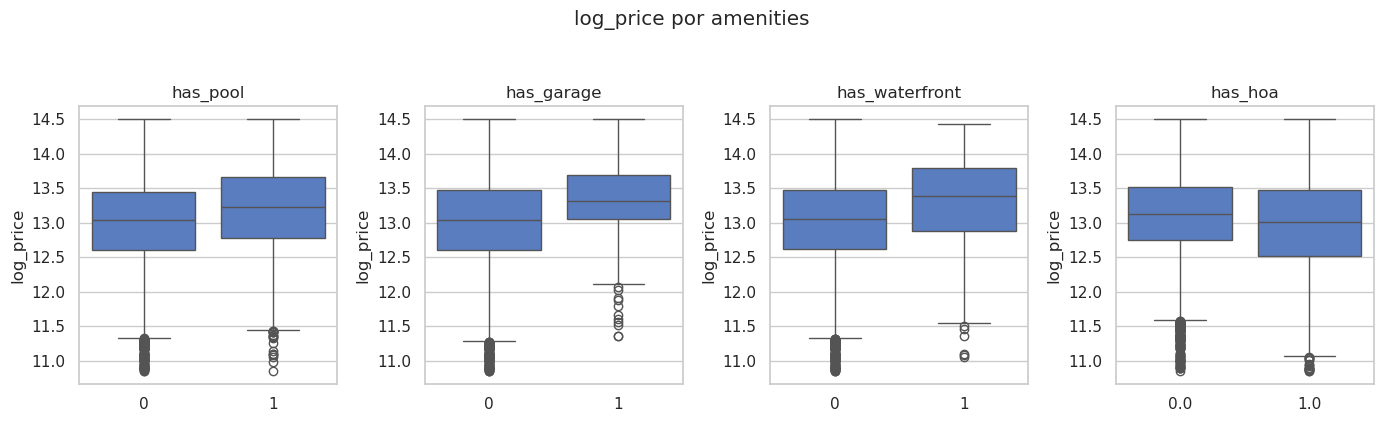

In [20]:
amenity_cols = ["has_pool", "has_garage", "has_waterfront", "has_hoa"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, amenity_cols):
    sns.boxplot(data=df, x=col, y="log_price", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("log_price por amenities", y=1.05)
plt.tight_layout()
plt.show()

## 10. Features de texto (descripción)

In [21]:
text_cols = ["desc_length", "desc_word_count", "desc_is_boilerplate"]
df[text_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
desc_length,11840.0,302.487838,326.000953,4.0,135.0,142.0,402.0,7540.0
desc_word_count,11840.0,50.211655,51.236522,1.0,25.0,27.0,63.0,1325.0
desc_is_boilerplate,11840.0,0.517314,0.499721,0.0,0.0,1.0,1.0,1.0


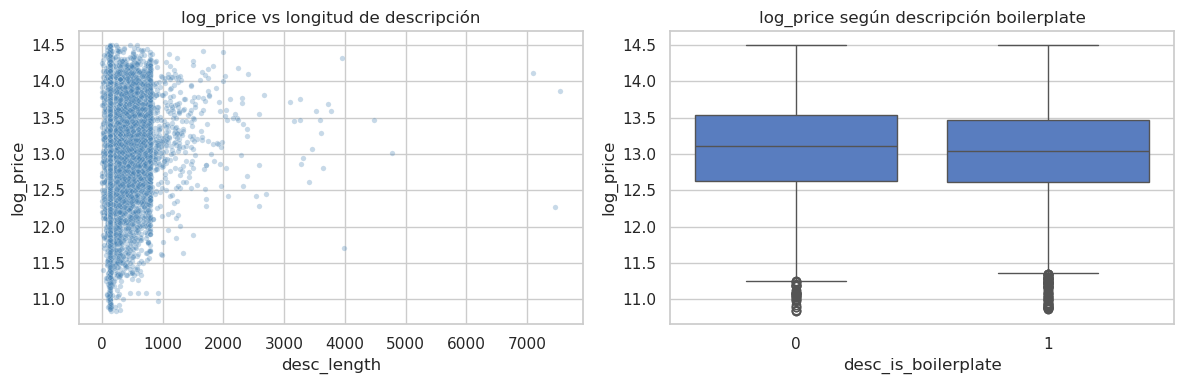

Descripciones boilerplate: 6125 (51.7%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=df, x="desc_length", y="log_price", alpha=0.3, s=15, ax=axes[0], color="steelblue")
axes[0].set_title("log_price vs longitud de descripción")

sns.boxplot(data=df, x="desc_is_boilerplate", y="log_price", ax=axes[1])
axes[1].set_title("log_price según descripción boilerplate")

plt.tight_layout()
plt.show()

print(f"Descripciones boilerplate: {df['desc_is_boilerplate'].sum()} ({df['desc_is_boilerplate'].mean()*100:.1f}%)")

In [23]:
print("Ejemplo de descripción:")
print(df["description"].iloc[0])

Ejemplo de descripción:
This 665 square foot condo home has 1 bedrooms and 1.0 bathrooms. This home is located at 511 Lucerne Ave APT 314, Lake Worth, FL 33460.


## 11. Conclusiones preliminares

**Dataset:** 11.840 propiedades en Florida, mayormente `SINGLE_FAMILY` y `CONDO`.

**Target (`log_price`):** distribución aproximadamente normal, sin outliers extremos.

**Correlaciones fuertes con el precio:**
- `taxAssessedValue` / `latest_tax_value` (~0.70)
- `livingArea` / `log_living_area` (~0.48)
- `bathrooms`, `bedrooms`, ratings de escuelas

**Missing values relevantes:**
- `lotAreaValue` / `log_lot_area`: ~45% faltante (esperable en condos)
- `last_listing_price`: ~33% faltante
- `bedrooms`, `bathrooms`, `livingArea`: <5% faltante

**Señales útiles para modelado:**
- Tipo de propiedad (`homeType`) separa claramente rangos de precio
- Amenities como `has_waterfront` y `has_pool` elevan el precio medio
- La ubicación (lat/lon, zipcode) captura variación geográfica
- Features de texto (`desc_mentions_*`) tienen baja prevalencia pero pueden aportar señal